# AI-Powered Meta-Software Development — Law Firm Website (DTS114TC CW)

This lab guides you through the process of transforming a real-world business problem into a complete software solution using AI-assisted development. You'll start by defining a business challenge, then use a large language model (LLM) to generate key software development lifecycle (SDLC) artifacts; including problem statements, personas, requirements, user stories, API endpoints, and test scripts. 

The lab demonstrates how to leverage AI tools to accelerate and automate each step, resulting in a working FlaskAPI application with comprehensive test coverage.

## Setup & Environment
Prepare the Python environment, import required libraries, and initialize the LLM client. This ensures reproducibility.

In [1]:
import os
import sys
# utils.py sits alongside this notebook
sys.path.insert(0, os.path.abspath(os.getcwd()))

try:
    from PIL import Image  # noqa: F401
    print("✅ Pillow already installed")
except Exception:
    print("Installing Pillow...")
    %pip install pillow

from utils import load_environment, get_completion

load_environment()
client, model_name, api_provider = None, None, None
try:
    from utils import setup_llm_client, clean_llm_output, recommended_models_table
    client, model_name, api_provider = setup_llm_client("openai/gpt-5.2")
    print(f"✅ LLM Client initialized: {api_provider} - {model_name}")
except Exception as e:
    print(f"❌ Error initializing LLM client: {e}")


✅ Pillow already installed
✅ LLM Client configured: Using 'apifree' with model 'openai/gpt-5.2'
✅ LLM Client initialized: apifree - openai/gpt-5.2


# Phase 1: Inception
Inception is the phase where business intent is converted into execution-ready context. This phase focuses on capturing Intents and translating them into Units for development.

An Intent is a high-level statement of purpose that encapsulates what needs to be achieved, serving as a starting point for the methodology. In this practical, we will be driven by the (1) business problem, (2) personas, (3) requirements, and (4) user stories.

In [2]:
# Edit the string below to define your business problem
business_problem = "Our law firm needs a website that introduces basic information about us, shows our lawyers and team, accepting potential customers to leave their contact info if they need and collecting feedback; For current customers, they can track lawyers' working progress on the website"

#### 1) AI generated –Business problem

In [3]:
if client and 'business_problem' in globals():
    print("--- Generating Problem Statement ---")
    prompt = f"Given the business problem below, generate one clear and concise problem statement.\nBusiness Problem: {business_problem}"
    problem_statement = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3
    )
    print(problem_statement)
else:
    print("Skipping step because LLM client or business problem is not available.")

--- Generating Problem Statement ---
Design and build a law firm website that presents firm and team information, enables prospective clients to submit contact details and feedback, and allows existing clients to securely track their case and lawyer progress online.


#### 2) AI generated –Personas (as in the Agile methodology)

In [4]:
if client and 'problem_statement' in globals():
    print("--- Generating Personas ---")
    prompt = (
        "Generate 2-4 user personas for the solution using this format:\n"
        "Personas: <one-sentence intro>\n\n"
        "1. **Role Title**\n   - **Responsibilities:** ...\n   - **Needs:** ...\n\n"
        "2. **Role Title**\n   - **Responsibilities:** ...\n   - **Needs:** ...\n\n"
        "Rules: Use single role titles only; no slashes (/) or combined titles. "
        "Keep each bullet concise.\n"
        f"Problem Statement: {problem_statement}"
    )
    personas = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3
    )
    print(f"Personas: {personas}")
else:
    print("Skipping step because LLM client or problem statement is not available.")

--- Generating Personas ---
Personas: Personas: Key users include prospective clients exploring services, existing clients monitoring active matters, and internal staff maintaining content and communication.

1. **Prospective Client**
   - **Responsibilities:** Research legal services, evaluate credibility, submit an inquiry or feedback.
   - **Needs:** Clear practice areas, attorney bios, trust signals, easy contact form, fast mobile experience.

2. **Existing Client**
   - **Responsibilities:** Track case status, review updates, communicate needs, provide documents or feedback.
   - **Needs:** Secure login, real-time case and lawyer progress visibility, messaging or update notifications, privacy assurances.

3. **Intake Coordinator**
   - **Responsibilities:** Manage incoming leads, route inquiries to lawyers, follow up, maintain client contact records.
   - **Needs:** Centralized form submissions, lead triage workflow, spam protection, templates for responses, audit trail.


#### 3) AI generated –Requirements based on the problem statement and personas

In [5]:
if client and 'problem_statement' in globals() and 'personas' in globals():
    print("--- Generating PRD ---")
    prompt = (
        "Write a PRD in markdown with these headings, each with 2-4 concise bullets:\n"
        "## Overview\n## Goals\n## Non-Goals\n## User Personas (brief)\n"
        "## Key Features\n## User Flows\n## Functional Requirements\n"
        "## Non-Functional Requirements\n## Constraints/Assumptions\n"
        "## Success Metrics\n## Open Questions\n\n"
        "Rules: Use only the headings above. No extra sections. Keep bullets short.\n"
        f"Problem Statement: {problem_statement}\n"
        f"Personas: {personas}"
    )
    prd = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3,
    )
    prd = clean_llm_output(prd, language='markdown')
    print(f"PRD: {prd}")
    # Ensure artifacts directory exists
    os.makedirs('artifacts', exist_ok=True)
    # Save PRD as Markdown
    with open('artifacts/prd.md', 'w') as f:
        f.write(prd)
    print('✅ Saved: artifacts/prd.md')
else:
    print("Skipping step because LLM client, problem statement, or personas are not available.")

--- Generating PRD ---
PRD: ## Overview
- Public-facing law firm site with firm, team, and practice information
- Lead intake via contact details and feedback submission
- Secure client portal for case status and lawyer progress tracking
- Admin tools for staff to manage content and inquiries

## Goals
- Build trust and convert prospective visitors into qualified inquiries
- Provide existing clients a secure, self-serve view of matter progress
- Streamline intake handling, routing, and follow-ups for staff
- Reduce manual status update requests via portal transparency

## Non-Goals
- Full document e-signing or payments processing at launch
- Replacing the firm’s primary case management system (CMS)
- Real-time chat/voice calling built into the site
- Marketing automation beyond basic notifications

## User Personas (brief)
- Prospective Client: learns services, evaluates credibility, submits inquiry/feedback
- Existing Client: logs in to track case/lawyer progress and receive updates s

#### 4) AI generated –User stories from the PRD and personas

In [6]:
if client and 'prd' in globals():
    print("--- Generating User Stories ---")
    prompt = (
        "Return ONLY valid JSON with this schema:\n"
        "{\n  \"user_stories\": [\n    {\n      \"id\": 1,\n      \"role\": \"<role>\",\n"
        "      \"goal\": \"<goal>\",\n      \"benefit\": \"<benefit>\",\n"
        "      \"acceptance_criteria\": [\"<criteria>\", \"<criteria>\"]\n    }\n  ]\n}\n\n"
        "Rules: Provide 5 stories. Keep each field concise. No extra keys.\n"
        f"PRD: {prd}"
    )
    user_stories = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3
    )
    user_stories = clean_llm_output(user_stories, language='json')
    print(f"User Stories: {user_stories}")
    # Save user stories as JSON
    import json, os
    os.makedirs('artifacts', exist_ok=True)
    user_stories_data = { 'user_stories': user_stories }
    with open('artifacts/user_stories.json', 'w') as f:
        json.dump(user_stories_data, f, indent=2)
    print('✅ Saved: artifacts/user_stories.json')
else:
    print("Skipping step because LLM client or PRD is not available.")

--- Generating User Stories ---
User Stories: {
  "user_stories": [
    {
      "id": 1,
      "role": "Prospective client",
      "goal": "Browse practice areas and attorney bios",
      "benefit": "Assess fit and credibility before contacting",
      "acceptance_criteria": [
        "Practice pages show services, FAQs, and disclaimers",
        "Attorney bios include credentials, focus areas, and contact CTA"
      ]
    },
    {
      "id": 2,
      "role": "Prospective client",
      "goal": "Submit an inquiry or feedback form",
      "benefit": "Receive clear next steps and a response",
      "acceptance_criteria": [
        "Form captures contact info, consent, matter type, and message",
        "User sees confirmation and receives receipt notification"
      ]
    },
    {
      "id": 3,
      "role": "Existing client",
      "goal": "Log in to the client portal securely",
      "benefit": "Access case information privately",
      "acceptance_criteria": [
        "Authenticatio

## Phase 2: Construction
Construction is the phase where AI plans and builds the system end-to-end using the established context, with humans validating outcomes. In this practical, we focus on (1) UML diagrams followed by the (2) product code.

#### 1) AI generated –UML diagrams

--- Generating PlantUML Use Case Diagram ---
Generated PlantUML diagram:
@startuml
actor "Prospective client" as ProspectiveClient
actor "Existing client" as ExistingClient
actor "Intake coordinator" as IntakeCoordinator

rectangle "Law Firm Website & Client Portal" {
  usecase "Browse practice areas" as UCBrowsePracticeAreas
  usecase "Browse attorney bios" as UCBrowseAttorneyBios
  usecase "Submit inquiry form" as UCSubmitInquiryForm
  usecase "Secure portal login" as UCSecurePortalLogin
  usecase "View matter status" as UCViewMatterStatus
  usecase "Route submissions" as UCRouteSubmissions
  usecase "Receive receipt notification" as UCReceiptNotification
  usecase "Assign submissions" as UCAssignSubmissions
  usecase "Label submissions" as UCLabelSubmissions
  usecase "Track submission outcome" as UCTrackOutcome
  usecase "Audit log actions" as UCAuditLog
  usecase "Send notifications" as UCSendNotifications
}

ProspectiveClient -- UCBrowsePracticeAreas
ProspectiveClient -- UCBrowse

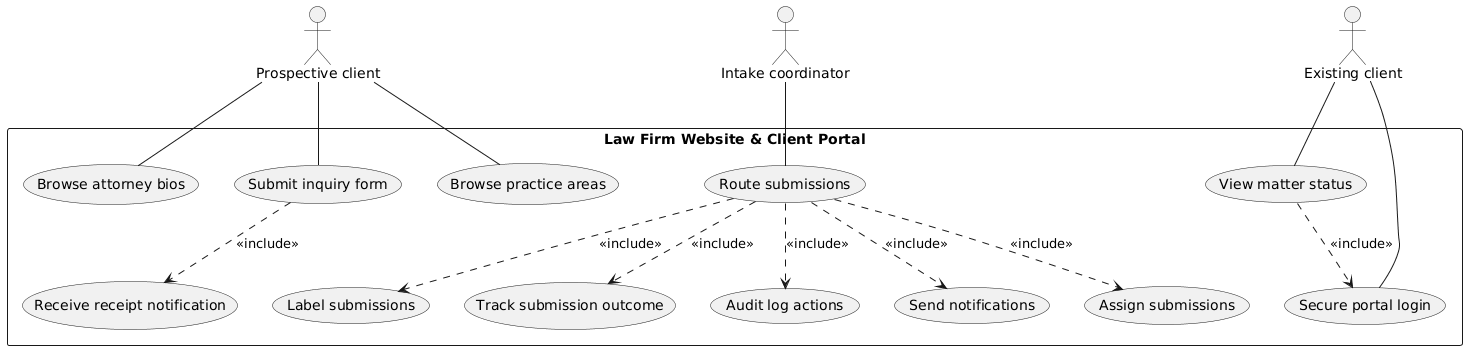

In [7]:
from utils import render_plantuml_diagram

if client and 'user_stories' in globals():
    print("--- Generating PlantUML Use Case Diagram ---")
    prompt = (
        "Generate a UML-compliant PlantUML use case diagram based on the user stories below.\n"
        "Use standard UML notation and PlantUML syntax.\n\n"
        "Required structure:\n"
        "@startuml\n"
        "actor ActorName\n"
        "actor AnotherActor\n\n"
        "rectangle \"System\" {\n"
        "  usecase \"Use Case Name\" as UC1\n"
        "  usecase \"Another Use Case\" as UC2\n"
        "}\n\n"
        "ActorName -- UC1\n"
        "AnotherActor -- UC2\n"
        "@enduml\n\n"
        "UML Rules:\n"
        "- Actors must be defined using the `actor` keyword and placed outside the system boundary\n"
        "- The system boundary must be a `rectangle` with a meaningful system name (default: \"System\")\n"
        "- Use cases must be defined using the `usecase` keyword and placed inside the system boundary\n"
        "- Associations between actors and use cases must use `--` (undirected association), not arrows\n"
        "- Do NOT number use case names; use clear verb–noun phrases instead\n"
        "- Extract unique actors from the `role` field in the user stories\n"
        "- Create one use case per distinct `goal` field\n"
        "- Keep use case names concise (max 5 words)\n"
        "- If a user story implies reuse, model it with `<<include>>`\n"
        "- If a user story implies optional or conditional behavior, model it with `<<extend>>`\n"
        "- Avoid layout directives unless necessary\n"
        "- Return ONLY valid PlantUML code, with no explanations or commentary\n\n"
        f"User Stories: {user_stories}"
    )

    puml = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3
    )
    puml = clean_llm_output(puml, language='text')
    print("Generated PlantUML diagram:")
    print(puml)
    
    # Save to file
    os.makedirs('artifacts/diagrams', exist_ok=True)
    with open('artifacts/diagrams/use_case_diagram.puml', 'w') as f:
        f.write(puml)
    print('✅ Saved: artifacts/diagrams/use_case_diagram.puml')
    render_plantuml_diagram(puml, "artifacts/diagrams/use_case_diagram.png")
else:
    print("Skipping step because LLM client or user_stories is not available.")



#### 2) AI generated Code

In [9]:
if client and 'user_stories' in globals():
    import json
    print("--- Generating Flask API App Code & Complementary Frontend ---")
    
    # Parse user stories
    try:
        stories_data = json.loads(user_stories) if isinstance(user_stories, str) else user_stories
        stories_list = stories_data if isinstance(stories_data, list) else stories_data.get('user_stories', [])
    except:
        print("Error parsing user stories")
        stories_list = []
    
    # Generate base app structure first
    base_app = get_completion(
        "Create a minimal Flask app skeleton with: from flask import Flask, request, jsonify, send_from_directory; app = Flask(__name__); in-memory storage using feedback_db = []; Add CORS support with from flask_cors import CORS; CORS(app); Add a health check endpoint GET /health that returns {status: ok}. Keep it under 20 lines.",
        client, model_name, api_provider, temperature=0.3
    )
    base_app = clean_llm_output(base_app, language='python')
    
    print(f"✅ Generated base app structure")
    
    # Generate endpoints for each user story iteratively
    endpoints_code = []
    for i, story in enumerate(stories_list[:3], 1):  # Limit to first 3 stories to keep it manageable
        story_text = f"Role: {story.get('role', '')}, Goal: {story.get('goal', '')}"
        print(f"  Generating endpoint {i}/3 for: {story.get('role', 'user')[:30]}...")
        
        endpoint_code = get_completion(
            f"Write 1-2 Flask endpoint functions for this user story: {story_text}. Use feedback_db list for storage. Return only the function code (e.g., @app.route decorated functions), no imports or app initialization. Keep under 25 lines. Ensure endpoints return JSON with proper status codes.",
            client, model_name, api_provider, temperature=0.3
        )
        endpoint_code = clean_llm_output(endpoint_code, language='python')
        endpoints_code.append(f"\n# Endpoint for Story {i}: {story.get('role', 'user')}\n{endpoint_code}")
    
    # Add a catch-all route to serve index.html
    frontend_route = """
# Serve frontend
@app.route('/')
def index():
    return send_from_directory('.', 'index.html')

@app.route('/<path:filename>')
def serve_static(filename):
    return send_from_directory('.', filename)
"""
    
    # Combine all code with Docker-compatible host binding
    main_py_code = base_app + "\n".join(endpoints_code) + frontend_route
    main_py_code += "\n\nif __name__ == '__main__':\n    # Bind to 0.0.0.0 to make it accessible from Docker\n    app.run(host='0.0.0.0', debug=True, port=5005)"
    
    os.makedirs('artifacts/app/flask', exist_ok=True)
    with open('artifacts/app/flask/main.py', 'w') as f:
        f.write(main_py_code)
    print('✅ Saved: artifacts/app/flask/main.py')
    
    # Extract endpoint routes for frontend integration
    import re
    route_pattern = r"@app\.route\(['\"]([^'\"]+)['\"](?:,\s*methods=\[([^\]]+)\])?\)"
    routes = re.findall(route_pattern, main_py_code)
    routes_text = ', '.join([f"{route} ({methods if methods else 'GET'})" for route, methods in routes])
    
    print(f"  Available API endpoints: {routes_text}")
    
    # Generate complementary HTML frontend that integrates with the API
    html_prompt = (
        "Generate a complete, production-ready HTML5 webpage that serves as a feedback collection system. "
        "Requirements: "
        "(1) Use Bootstrap 5 CSS framework via CDN for professional styling. "
        "(2) Include a form with input fields for: user name (text), email address (email), feedback message (textarea), and rating (select 1-5). "
        "(3) Add a Submit button that sends form data via POST request to http://127.0.0.1:5005/feedback as JSON. "
        "(4) Add a section that fetches and displays all existing feedback from http://127.0.0.1:5005/feedback using GET request. "
        "(5) Display feedback in a card or list format with name, rating, and message visible. "
        "(6) Include client-side form validation (all fields required). "
        "(7) Show success/error messages after form submission using alerts. "
        "(8) Handle network errors gracefully with user-friendly error messages. "
        "(9) Include all CSS styling inline in <style> tags. "
        "(10) Include all JavaScript logic inline in <script> tags. "
        "(11) Use Fetch API for all HTTP requests. (12) Include a prominent hero section that displays images/hero.png (AI-generated law firm banner). Add CSS class hero-image for the banner. (12) Include a prominent hero section that displays images/hero.png (AI-generated law firm banner). Add CSS class hero-image for the banner. "
        "Output ONLY the complete, valid HTML document. No explanations or markdown."
    )
    
    html_code = get_completion(
        html_prompt, client, model_name, api_provider, temperature=0.4
    )
    html_code = clean_llm_output(html_code, language='html')
    
    # Save HTML file
    with open('artifacts/app/flask/index.html', 'w', encoding='utf-8') as f:
        f.write(html_code)
    print('✅ Saved: artifacts/app/flask/index.html')
    
    # Generate README.md with integration instructions
    readme_content = get_completion(
        "Write a README.md (under 250 words) for an integrated Flask feedback API with HTML frontend. Include: title, description, setup (pip install flask flask-cors), run command (python main.py), how to access the app (http://127.0.0.1:5005), and 2 curl examples for POST /feedback and GET /feedback endpoints. Also mention the interactive HTML frontend is served automatically.",
        client, model_name, api_provider, temperature=0.3
    )
    with open('artifacts/app/flask/README.md', 'w') as f:
        f.write(readme_content)
    print('✅ Saved: artifacts/app/flask/README.md')
    print("\n✅ API and Frontend code generated and saved successfully!")
else:
    print("Skipping step because LLM client or user_stories is not available.")

--- Generating Flask API App Code & Complementary Frontend ---
✅ Generated base app structure
  Generating endpoint 1/3 for: Prospective client...
  Generating endpoint 2/3 for: Prospective client...
  Generating endpoint 3/3 for: Existing client...
✅ Saved: artifacts/app/flask/main.py
  Available API endpoints: /practice-areas ("GET"), /attorneys ("GET"), /feedback ("POST"), /feedback/<int:feedback_id> ("GET"), /api/login ("POST"), /api/logout ("POST"), / (GET), /<path:filename> (GET)
✅ Saved: artifacts/app/flask/index.html
✅ Saved: artifacts/app/flask/README.md

✅ API and Frontend code generated and saved successfully!


In [11]:
# Generate a hero image for the law firm website and embed it in the frontend
from utils import get_image_generation_completion, setup_llm_client

if client and os.path.exists('artifacts/app/flask'):
    print("--- Generating Hero Image for Law Firm Website ---")
    os.makedirs('artifacts/app/flask/images', exist_ok=True)
    image_prompt = (
        "Professional law firm website hero banner: modern office interior, "
        "scales of justice subtly visible, blue and gold colour palette, "
        "clean corporate style, no text, suitable for a legal services homepage."
    )
    img_client, img_model, img_provider = setup_llm_client("qwen/qwen-image-2512")
    file_path, image_url = get_image_generation_completion(
        image_prompt, img_client, img_model, img_provider
    )
    if file_path and os.path.exists(file_path):
        import shutil
        dest = 'artifacts/app/flask/images/hero.png'
        shutil.copy(file_path, dest)
        print(f'✅ Saved hero image: {dest}')
    elif file_path is None:
        print(f'⚠️ Image generation issue: {image_url}')

    # Ensure index.html displays the generated image prominently
    index_path = 'artifacts/app/flask/index.html'
    if os.path.exists(index_path):
        with open(index_path, 'r', encoding='utf-8') as f:
            html = f.read()
        hero_tag = '<img src="images/hero.png" alt="Law firm hero banner" class="hero-image" style="width:100%;max-height:320px;object-fit:cover;border-radius:8px;margin-bottom:1.5rem;">'
        if 'images/hero.png' not in html:
            if '<body' in html:
                html = html.replace('<body>', f'<body>\n{hero_tag}', 1)
                html = html.replace('<body ', f'<body>\n{hero_tag}\n<body ', 1) if '<body>' not in html else html
            elif '<main' in html:
                html = html.replace('<main', hero_tag + '\n<main', 1)
            else:
                html = hero_tag + html
            with open(index_path, 'w', encoding='utf-8') as f:
                f.write(html)
            print('✅ Embedded hero image in index.html')
        else:
            print('✅ index.html already references hero.png')
else:
    print("Skipping image step: LLM client unavailable or Flask app not generated.")


--- Generating Hero Image for Law Firm Website ---
✅ LLM Client configured: Using 'apifree' with model 'qwen/qwen-image-2512'
Generating image... This may take a moment.


⏳ Generating image...

Still generating image... (poll 5/60)
✅ Image generated in 32.15 seconds.
✅ Image saved to: artifacts\artifacts\screens\image_1780124037188.png
✅ Saved hero image: artifacts/app/flask/images/hero.png
✅ index.html already references hero.png


In [12]:
if client and os.path.exists('artifacts/app/flask/main.py'):
    print("--- Generating requirements.txt ---")
    
    # Read the app code
    with open('artifacts/app/flask/main.py', 'r') as f:
        app_code = f.read()
    
    # Extract only import statements from the beginning of the file
    import_lines = []
    for line in app_code.split('\n'):
        stripped = line.strip()
        if stripped.startswith('import ') or stripped.startswith('from '):
            import_lines.append(stripped)
        elif stripped and not stripped.startswith('#'):
            # Stop at first non-import, non-comment line
            break
    
    imports_text = '\n'.join(import_lines)
    print(f"  Found {len(import_lines)} import statement(s)")
    
    # Generate requirements based on imports only
    requirements = get_completion(
        f"Based on these Python import statements, list all required package dependencies (one per line). Include only package names, no version constraints. Remove duplicates and standard library. Import statements:\n{imports_text}",
        client, model_name, api_provider, temperature=0.3
    )
    requirements = clean_llm_output(requirements, language='text')
    
    # Parse and clean requirements
    req_lines = [line.strip() for line in requirements.split('\n')]
    req_lines = [line for line in req_lines if line and not line.startswith('#')]  # Remove empty lines and comments
    req_set = set(req_lines)  # Remove duplicates
    req_list = sorted(list(req_set))  # Sort for consistency
    
    # Reconstruct clean requirements
    clean_requirements = '\n'.join(req_list)
    
    with open('artifacts/app/flask/requirements.txt', 'w') as f:
        f.write(clean_requirements)
    print(f'✅ Saved: artifacts/app/flask/requirements.txt ({len(req_list)} packages)')
    print(f"  Packages: {', '.join(req_list)}")
else:
    print("Skipping step because Flask app is not available.")

--- Generating requirements.txt ---
  Found 2 import statement(s)
✅ Saved: artifacts/app/flask/requirements.txt (2 packages)
  Packages: flask, flask-cors


## Phase 3: Operation
AI oversees deployments, infrastructure-as-code, monitoring, and ongoing operations based on the accumulated project context. The team continues oversight and governance.

As for this practical and due to the scope of the lab, we will limit to package the application into a Docker container for easy deployment and reproducibility.

In [13]:
import os

# Generate Dockerfile for the Flask application
dockerfile_content = """FROM python:3.11-slim

# Set working directory
WORKDIR /app

# Copy requirements and install dependencies
COPY flask/requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# Copy application files
COPY flask/ .

# Expose port
EXPOSE 5005

# Set environment variables
ENV FLASK_APP=main.py
ENV FLASK_ENV=production

# Run the application
CMD ["python", "main.py"]
"""

# Generate .dockerignore file
dockerignore_content = """__pycache__
*.pyc
*.pyo
*.pyd
.Python
env/
venv/
.venv
.git
.gitignore
.env
.DS_Store
*.egg-info
dist
build
.pytest_cache
"""

# Generate docker-compose.yml for orchestration
docker_compose_content = """version: '3.8'

services:
  flask-app:
    build:
      context: .
      dockerfile: docker/Dockerfile
    container_name: feedback-app
    ports:
      - "5005:5005"
    environment:
      - FLASK_ENV=production
      - FLASK_APP=main.py
    volumes:
      - ./flask:/app
    restart: unless-stopped
"""

# Create Docker configuration files
if os.path.exists('artifacts/app/flask/main.py'):
    print("--- Generating Docker Configuration Files ---")
    
    # Ensure docker directory exists
    os.makedirs('artifacts/app/docker', exist_ok=True)
    
    # Save Dockerfile
    with open('artifacts/app/docker/Dockerfile', 'w') as f:
        f.write(dockerfile_content)
    print('✅ Saved: artifacts/app/docker/Dockerfile')
    
    # Save .dockerignore
    with open('artifacts/app/docker/.dockerignore', 'w') as f:
        f.write(dockerignore_content)
    print('✅ Saved: artifacts/app/docker/.dockerignore')
    
    # Save docker-compose.yml in artifacts/app
    with open('artifacts/app/docker-compose.yml', 'w') as f:
        f.write(docker_compose_content)
    print('✅ Saved: artifacts/app/docker-compose.yml')
    
    print("\n--- Docker Build & Run Instructions ---")
    print("""
📦 To build and run the Docker container:

IMPORTANT: All commands must be run from the artifacts/app directory!

1. Navigate to the app directory:
   cd artifacts/app

2. Build the Docker image:
   docker build -t feedback-app:latest -f docker/Dockerfile .

3. Run the container:
   docker run -p 5005:5005 feedback-app:latest

4. Alternative: Use Docker Compose (recommended):
   docker-compose up --build

5. Access the application:
   Open http://127.0.0.1:5005 in your browser

6. View logs:
   docker logs -f feedback-app

7. Stop the container:
   docker stop feedback-app
   
8. Clean up:
   docker-compose down
    """)
    
    print("\n✅ Docker containerization setup complete!")
else:
    print("❌ Flask app not found. Please run the code generation cell first.")

--- Generating Docker Configuration Files ---
✅ Saved: artifacts/app/docker/Dockerfile
✅ Saved: artifacts/app/docker/.dockerignore
✅ Saved: artifacts/app/docker-compose.yml

--- Docker Build & Run Instructions ---

📦 To build and run the Docker container:

IMPORTANT: All commands must be run from the artifacts/app directory!

1. Navigate to the app directory:
   cd artifacts/app

2. Build the Docker image:
   docker build -t feedback-app:latest -f docker/Dockerfile .

3. Run the container:
   docker run -p 5005:5005 feedback-app:latest

4. Alternative: Use Docker Compose (recommended):
   docker-compose up --build

5. Access the application:
   Open http://127.0.0.1:5005 in your browser

6. View logs:
   docker logs -f feedback-app

7. Stop the container:
   docker stop feedback-app

8. Clean up:
   docker-compose down
    

✅ Docker containerization setup complete!
